In [1]:
import pandas as pd
import numpy as np

# 1. توليد بيانات افتراضية لـ 1000 عميل
np.random.seed(42)
data = {
    'Age': np.random.randint(18, 70, 1000),
    'Tenure_Months': np.random.randint(1, 72, 1000),
    'Monthly_Charges': np.random.uniform(20.0, 120.0, 1000),
    'Contract_Type': np.random.choice(['Month-to-month', 'One year', 'Two year'], 1000),
    'Tech_Support': np.random.choice(['Yes', 'No'], 1000),
    # صناعة النتيجة (Churn) بحيث تكون مرتبطة منطقياً بالبيانات
    'Churn': np.where(np.random.rand(1000) > 0.7, 1, 0)
}

df = pd.DataFrame(data)
df

,Age,Tenure_Months,Monthly_Charges,Contract_Type,Tech_Support,Churn
0,56,15,55.162269,One year,Yes,0
1,69,64,30.142083,Month-to-month,No,0
2,46,28,68.587176,One year,No,0
3,32,39,45.677657,Month-to-month,No,1
4,60,57,48.487290,Two year,Yes,0
...,...,...,...,...,...,...
995,60,51,67.684347,One year,Yes,1
996,64,15,88.772204,Two year,Yes,0
997,62,68,92.270696,Month-to-month,No,1
998,35,21,89.253243,Month-to-month,Yes,0


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Age              1000 non-null   int32  
 1   Tenure_Months    1000 non-null   int32  
 2   Monthly_Charges  1000 non-null   float64
 3   Contract_Type    1000 non-null   object 
 4   Tech_Support     1000 non-null   object 
 5   Churn            1000 non-null   int64  
dtypes: float64(1), int32(2), int64(1), object(2)
memory usage: 39.2+ KB


In [3]:
df.describe()

,Age,Tenure_Months,Monthly_Charges,Churn
count,1000.00000,1000.00000,1000.000000,1000.000000
mean,43.81900,35.45900,69.976592,0.278000
std,14.99103,20.36819,28.622115,0.448238
min,18.00000,1.00000,20.156511,0.000000
25%,31.00000,17.75000,45.739956,0.000000
50%,44.00000,36.00000,70.620396,0.000000
75%,56.00000,53.00000,94.329338,1.000000
max,69.00000,71.00000,119.834751,1.000000


In [4]:
df.isnull().sum()

Age                0
Tenure_Months      0
Monthly_Charges    0
Contract_Type      0
Tech_Support       0
Churn              0
dtype: int64

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

C:\Users\IT\AppData\Local\Temp\ipykernel_16696\1854759976.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Churn', palette='Set2')


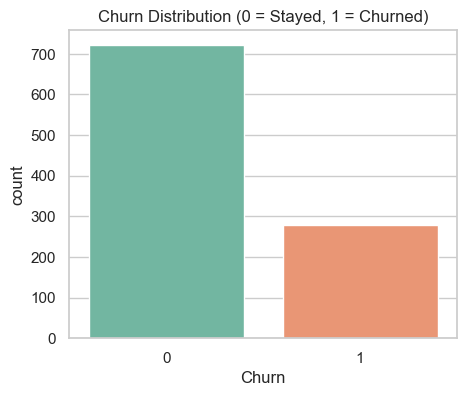

In [6]:
# Count Plot

plt.figure(figsize=(5,4))
sns.countplot(data=df, x='Churn', palette='Set2')
plt.title('Churn Distribution (0 = Stayed, 1 = Churned)')
plt.show()

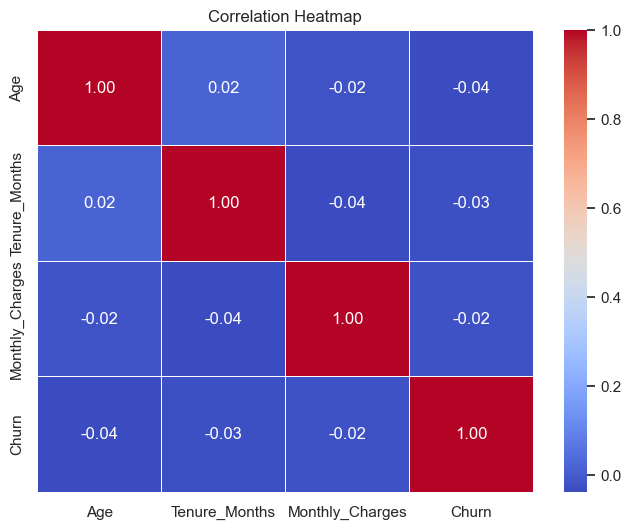

In [7]:
# Correlation Heatmap

plt.figure(figsize=(8,6))
cols = ['Age', 'Tenure_Months', 'Monthly_Charges', 'Churn']
correlation_matrix = df[cols].corr()


sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()


C:\Users\IT\AppData\Local\Temp\ipykernel_16696\3673845780.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y='Tenure_Months', ax=axes[0], palette='Set1')
C:\Users\IT\AppData\Local\Temp\ipykernel_16696\3673845780.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y='Monthly_Charges', ax=axes[1], palette='Set1')


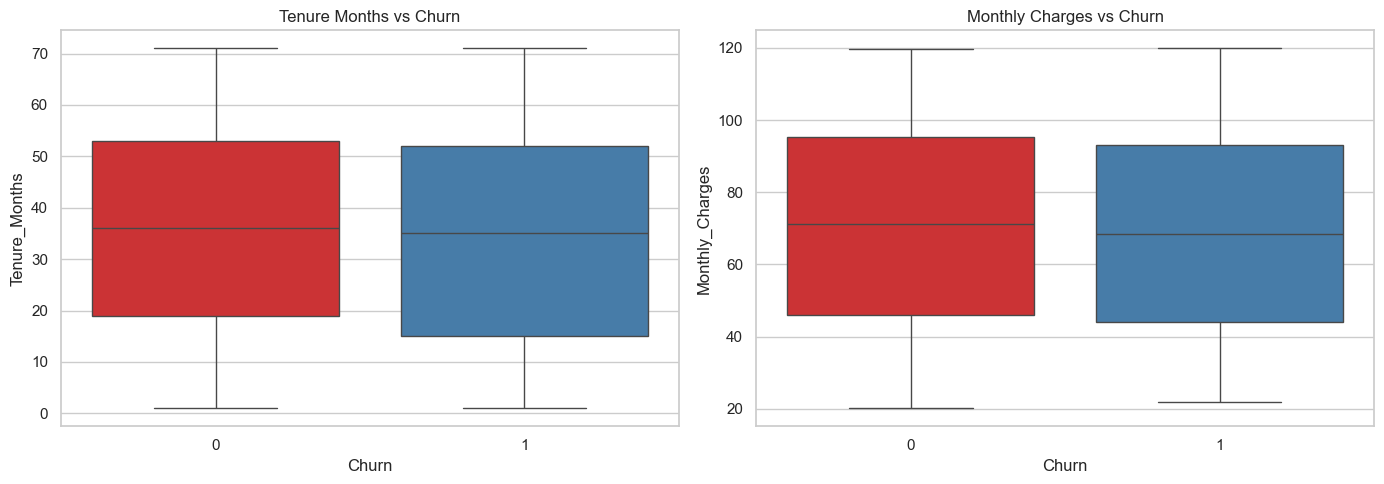

In [8]:
# Box Plots

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# First Fund: Subscription Period
sns.boxplot(data=df, x='Churn', y='Tenure_Months', ax=axes[0], palette='Set1')
axes[0].set_title('Tenure Months vs Churn')

# Box 2: Monthly Bill
sns.boxplot(data=df, x='Churn', y='Monthly_Charges', ax=axes[1], palette='Set1')
axes[1].set_title('Monthly Charges vs Churn')

plt.tight_layout()
plt.show()

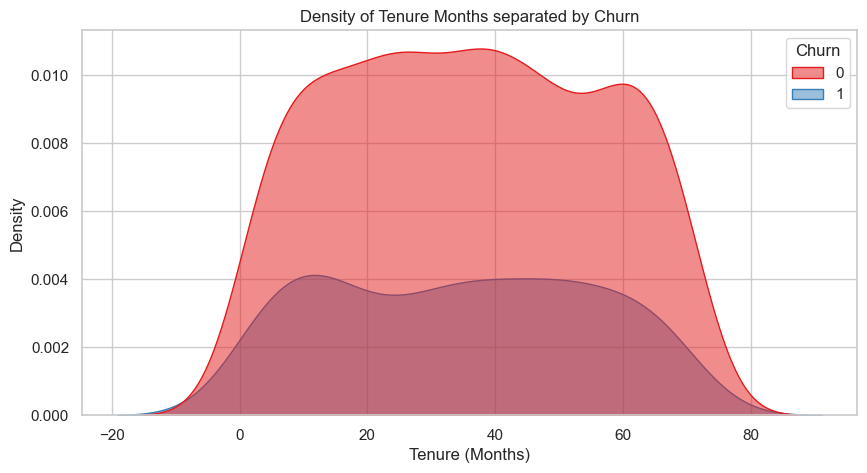

In [9]:
# KDE Plot

plt.figure(figsize=(10, 5))
sns.kdeplot(data=df, x='Tenure_Months', hue='Churn', fill=True, palette='Set1', alpha=0.5)
plt.title('Density of Tenure Months separated by Churn')
plt.xlabel('Tenure (Months)')
plt.ylabel('Density')
plt.show()

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [11]:
X = df.drop('Churn', axis=1)
y = df['Churn']

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [13]:
numeric_features = ['Age', 'Tenure_Months', 'Monthly_Charges']
categorical_features = ['Contract_Type', 'Tech_Support']

In [14]:
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(), categorical_features)
])

In [15]:
models = {
    'LogisticRegression': LogisticRegression(),
    'DecisionTree': DecisionTreeClassifier(),
    'RandomForest': RandomForestClassifier()
}

In [16]:
print("--- نتائج تقييم الموديلات ---")

--- نتائج تقييم الموديلات ---


In [17]:
for name , model in models.items():
  clf_pipline = Pipeline(steps=[
      ('preprocessor', preprocessor),
      ('classifier', model)
  ])

In [18]:
clf_pipline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [19]:
predictions = clf_pipline.predict(X_test)

In [20]:
accuracy = accuracy_score(y_test, predictions)
print(f"{name} Accuracy: {accuracy*100 :.2f}")

RandomForest Accuracy: 64.50


In [21]:
# Hyperparameter Tuning (Random Forest)

from sklearn.model_selection import GridSearchCV

rf_pipline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

In [22]:
param_grid = {
    'classifier__n_estimators': [50, 100, 200],
    'classifier__max_depth': [None, 5, 10],
    'classifier__min_samples_split': [2, 5]
}

In [23]:
grid_search = GridSearchCV(
    estimator=rf_pipline,
    param_grid=param_grid,
    cv=3,
    n_jobs=-1,
    verbose=1
)

In [24]:
print("Starting Grid Search... This might take a moment.")
grid_search.fit(X_train, y_train)


Starting Grid Search... This might take a moment.
Fitting 3 folds for each of 18 candidates, totalling 54 fits


,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'classifier__max_depth': [None, 5, ...], 'classifier__min_samples_split': [2, 5], 'classifier__n_estimators': [50, 100, ...]}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,3
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [25]:
best_model = grid_search.best_estimator_

In [26]:
best_predictions = best_model.predict(X_test)

In [27]:
best_accuracy = accuracy_score(y_test, best_predictions)

In [28]:
print("\n--- Optimization Complete ---")
print(f"Optimal Parameters Discovered: {grid_search.best_params_}")
print(f"Optimized Random Forest Accuracy: {best_accuracy * 100:.2f}%")


--- Optimization Complete ---
Optimal Parameters Discovered: {'classifier__max_depth': 5, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 100}
Optimized Random Forest Accuracy: 71.50%


In [29]:
# (Deep Evaluation)

import joblib
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

In [30]:
print("--- Detailed Classification Report ---")
print(classification_report(y_test, predictions))

--- Detailed Classification Report ---
              precision    recall  f1-score   support

           0       0.70      0.88      0.78       143
           1       0.15      0.05      0.08        57

    accuracy                           0.65       200
   macro avg       0.42      0.47      0.43       200
weighted avg       0.54      0.65      0.58       200



In [31]:
cm = confusion_matrix(y_test, best_predictions)

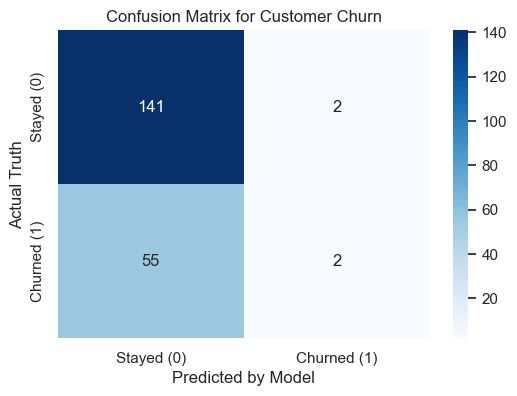

In [32]:
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stayed (0)', 'Churned (1)'],
            yticklabels=['Stayed (0)', 'Churned (1)'])
plt.title('Confusion Matrix for Customer Churn')
plt.xlabel('Predicted by Model')
plt.ylabel('Actual Truth')
plt.show()

In [33]:
model_filename = 'churn_prediction_pipeline.pkl'
joblib.dump(best_model, model_filename)
print(f"\nSuccess! The model has been saved as '{model_filename}'")


Success! The model has been saved as 'churn_prediction_pipeline.pkl'
